# Otros modelos de crecimiento

In [5]:
# import functions

from utils_sim import *

Aquí están de nuevo los datos descargados en el notebook anterior.

In [6]:
from pandas import read_html

filename = 'World_population_estimates.html'
tables = read_html(filename, header=0, index_col=0, decimal='M')
table2 = tables[2]
table2.columns = ['census', 'prb', 'un', 'maddison', 
                  'hyde', 'tanton', 'biraben', 'mj', 
                  'thomlinson', 'durand', 'clark']

In [7]:
un = table2.un / 1e9
census = table2.census / 1e9

In [8]:
def plot_estimates():
    census.plot(style=':', label='US Census')
    un.plot(style='--', label='UN DESA')
    decorar(xlabel='Year', 
             ylabel='World population (billions)') 

Hasta ahora hemos desarrollado un modelo de población donde el crecimiento neto depende de la población actual, y vimos que el modelo proporcional mejora al modelo de crecimiento constante, pero no se ajusta tan bien a los datos.

Hay algunas cosas que podríamos intentar para mejorar el modelo:

-   Tal vez el crecimiento neto dependa de la población actual, pero la relación sea cuadrática, no lineal.

-   Tal vez la tasa de crecimiento neto varíe con el tiempo.

En este notebook exploraremos la primera opción.

## Crecimiento cuadrático

Tiene sentido que el crecimiento neto dependa de la población actual, pero quizá no sea una relación lineal, como esta:

```
net_growth = system.alpha * pop
```

Quizá sea una relación cuadrática, como esta:

```
net_growth = system.alpha * pop + system.beta * pop**2
```

Podemos poner a prueba esta conjetura con una nueva función de actualización:

In [9]:
def growth_func_quad(t, pop, system):
    return system.alpha * pop + system.beta * pop**2

Este es el objeto `System` que usaremos, inicializado con `t_0`, `p_0` y `t_end`.

In [10]:
t_0 = census.index[0]
p_0 = census[t_0]
t_end = census.index[-1]

system = System(t_0=t_0,
                p_0=p_0,
                t_end=t_end)

Ahora tenemos que añadir los parámetros `alpha` y `beta`.
Elegí los siguientes valores por prueba y error; veremos mejores maneras de hacerlo más adelante.

In [11]:
system.alpha = 25 / 1000
system.beta = -1.8 / 1000

Y así es como lo ejecutamos:

In [12]:
results = run_simulation(system, growth_func_quad)

Aquí están los resultados.

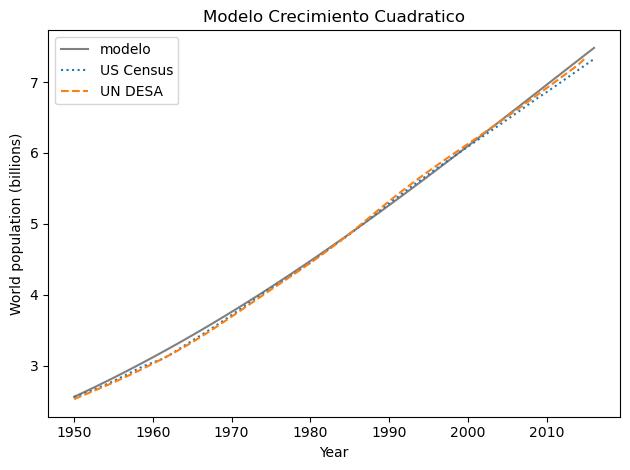

In [13]:
results.plot(color='gray', label='modelo')
plot_estimates()
decorar(title='Modelo Crecimiento Cuadratico')

El modelo se ajusta bien a los datos en todo el rango, con apenas un poco de separación entre ellos en la década de 1960.

No es del todo sorprendente que el modelo cuadrático se ajuste mejor que los modelos de crecimiento constante y proporcional, porque tiene dos parámetros que podemos elegir, mientras que los otros modelos tienen solo uno. En general, cuanto más parámetros tengas para ajustar, mejor deberías esperar que se ajuste el modelo.

Pero ajustar los datos no es la única razón para pensar que el modelo cuadrático podría ser una buena elección. También tiene sentido; es decir, hay una razón válida para esperar que la relación entre crecimiento y población tenga esta forma.

Para entenderlo, veamos el crecimiento neto como función de la población.

## Crecimiento neto

Grafiquemos la relación entre crecimiento y población en el modelo cuadrático.
Usaré `linspace` para crear un arreglo de 101 valores de población de 0 a 15 mil millones.

In [14]:
from numpy import linspace

pop_array = linspace(0, 15, 101)

Ahora usaré el modelo cuadrático para calcular el crecimiento neto para cada población.

In [15]:
growth_array = (system.alpha * pop_array + 
                system.beta * pop_array**2)

Para graficar la tasa de crecimiento frente a la población, usaremos la función `plot` de Matplotlib.
Primero tenemos que importarla:

In [16]:
from matplotlib.pyplot import plot

Ahora podemos usarla así:

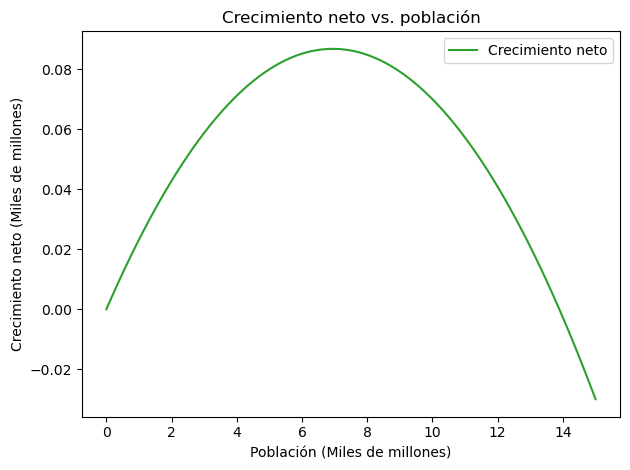

In [17]:
plot(pop_array, growth_array, label='Crecimiento neto', color='C2')

decorar(xlabel='Población (Miles de millones)',
         ylabel='Crecimiento neto (Miles de millones)',
         title='Crecimiento neto vs. población')

Observa que el eje x no es el tiempo, como en las figuras anteriores, sino la población. Podemos dividir esta curva en cuatro tipos de comportamiento:

-   Cuando la población es menor que 3 mil millones, el crecimiento neto es proporcional a la población, como en el modelo proporcional. En este rango, la población crece lentamente porque la población es pequeña.

-   Entre 3 mil millones y 10 mil millones, la población crece rápidamente porque hay mucha gente.

-   Por encima de 10 mil millones, la población crece más lentamente; este comportamiento modela el efecto de las limitaciones de recursos que disminuyen las tasas de natalidad o aumentan las tasas de mortalidad.

-   Por encima de 14 mil millones, los recursos son tan limitados que la tasa de mortalidad supera la tasa de natalidad y el crecimiento neto se vuelve negativo.

Justo por debajo de 14 mil millones, hay un punto en el que el crecimiento neto es 0, lo que significa que la población no cambia. En este punto, las tasas de natalidad y de mortalidad son iguales, por lo que la población está en *equilibrio*.

## Encontrar el equilibrio

El punto de equilibrio es la población, $p$, donde el crecimiento neto de la población, $\Delta p$, es 0.
Podemos calcularlo encontrando las raíces, o ceros, de esta ecuación: 

$\Delta p = \alpha p + \beta p^2$

donde $\alpha$ y $\beta$ son los parámetros del modelo. 
Si reescribimos el lado derecho así: 

$\Delta p = p (\alpha + \beta p)$

podemos ver que el crecimiento neto es $0$ cuando $p=0$ o $p=-\alpha/\beta$.
Así que podemos calcular el punto de equilibrio (distinto de cero) de esta manera:

In [ ]:
-system.alpha / system.beta

Con estos parámetros, el crecimiento neto es 0 cuando la población es de aproximadamente 13,9 mil millones (el resultado es positivo porque `beta` es negativa).

En el contexto del modelado de población, el modelo cuadrático se escribe más convencionalmente así: 

$\Delta p = r p (1 - p / K)$

Es el mismo modelo; solo es otra forma de *parametrizarlo*. Dados $\alpha$ y $\beta$, podemos calcular $r=\alpha$ y $K=-\alpha/\beta$.

En esta versión, es más fácil interpretar los parámetros: $r$ es la tasa de crecimiento sin restricciones, observada cuando $p$ es pequeña, y $K$ es el punto de equilibrio. 
A $K$ también se le llama *capacidad de carga*, ya que indica la población máxima que el entorno puede sostener.

## Resumen

En este notebook implementamos un modelo de crecimiento cuadrático donde el crecimiento neto depende de la población actual y del cuadrado de la población. Este modelo se ajusta bien a los datos, y vimos una razón de ello: tiene sentido si existe un límite para el número de personas que la Tierra puede soportar.

En el próximo capítulo usaremos los modelos que hemos desarrollado para generar predicciones.

En este ejemplo, `carrying_capacity` se ejecuta y devuelve `K`, pero el valor de retorno no se muestra ni se asigna a una variable.
Si intentamos imprimir `K`, obtenemos un `NameError`, porque `K` solo existe dentro de la función.

Cuando llamas a una función que devuelve un valor, deberías hacer algo con el resultado.

## Ejercicios

### Ejercicio 1

En una sección anterior, vimos otra forma de parametrizar el modelo cuadrático:

$$ \Delta p = r p (1 - p / K) $$

donde $r=\alpha$ y $K=-\alpha/\beta$.  

Escribe una versión de `growth_func` que implemente esta versión del modelo, vuelve a evaluar el modelo con `alpha=0.025` y `beta=-0.0018`, y confirma que obtienes los mismos resultados.

In [ ]:
# La solución va aqui

### Ejercicio 2

¿Qué ocurre si comenzamos con una población inicial por encima del punto de equilibrio? Simula diversos valores iniciales entre 1 y 20 mil millones y grafica los resultados en los mismos ejes.

Ayuda: Si hay demasiadas etiquetas en la leyenda, puedes graficar los resultados así:

```
    results.plot(label='_nolegend')
```

In [ ]:
# La solución va aqui